In [ ]:
import os
import itertools

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, Dropout,BatchNormalization

import warnings
warnings.filterwarnings('ignore')

print("Modules Loaded")

Modules Loaded


In [ ]:
import os
import cv2
import glob
import math
import time
import random
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
import multiprocessing
import tensorflow as tf
from pathlib import Path
import concurrent.futures
import keras.backend as K
from time import perf_counter
from functools import lru_cache
import matplotlib.pyplot as plt
from keras import layers, models
from keras.optimizers import Adam
from PIL import Image, ImageEnhance
from joblib import Parallel, delayed
from collections import defaultdict, Counter
from sklearn.preprocessing import LabelEncoder
from keras.metrics import Precision, Recall, AUC
from keras.callbacks import LearningRateScheduler
from keras.utils import plot_model, to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from concurrent.futures import ThreadPoolExecutor, as_completed
from sklearn.metrics import accuracy_score, classification_report

### Preprocessing

#### Read data and store in df

In [ ]:
def main(train_data_path):

    """
    return training and testing dataframes including 2 columns image path and its label

    Args:
      train_data_path (string): string includes your train data path
      test_data_path (string): string includes your test data path
      note: data_path argument must contains your classes dirs

    Returns:
      train_df (dataframe):  It consists of two columns (the path of the image and its label) and contains records of the path of the training images and the label of each image
      test_df (dataframe):  It consists of two columns (the path of the image and its label) and contains records of the path of the testing images and the label of each image

    """

    for dirs in [train_data_path]:

        filepaths = []
        labels = []
        classes_list = sorted(os.listdir(dirs))

        filepaths,labels = get_fileList(classes_list, dirs, filepaths, labels)

        train_df = obtain_train_df(filepaths, labels)


    return train_df



def get_fileList(classes_list, dirs, filepaths, labels):


    """
    return file paths list including all full image paths and label for each one

    Args:
      classes_list (list): list includes name of classes dirs
      dirs (string): the data path
      filepaths (list): empty list to fill with images paths later
      labels (list): empty list to fill with each image label later

    Returns:
      count (scalar):  number of images in your dataset
    """


    for s_class in classes_list:

        label = s_class
        classpath = os.path.join(dirs, s_class)
        flist = sorted(os.listdir(classpath))

        store_image_names_and_its_labels(flist, classpath, filepaths, labels, label)

    return filepaths, labels


def store_image_names_and_its_labels(flist, classpath, filepaths, labels, label):

    """
    return nothing, it fills the filepaths list with all the images paths and its labels

    Args:
      flist (list) : contains all the image names in certain class
      classes_list (list): list includes name of classes dirs
      filepaths (list): stores all the images paths
      labels (list): stores the label of each image in the dataset
      label (string): label for a specific image

    Returns:
      nothing
    """


    for file in flist:
        file_path = os.path.join(classpath, file)
        filepaths.append(file_path)
        labels.append(label)



def obtain_train_df(filepaths, labels):

    """
    Return Dataframe with 2 columns contains each image path with its label

    Args:
      filepaths (list): stores all the images paths
      labels (list): stores the label of each image in the dataset

    Returns:
      train_df (DataFrame):  Dataframe with 2 columns contains each image path with its label
    """

    train_df =pd.DataFrame({
        'image_path' : filepaths,
        'label' : labels
    })
    return train_df

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!pip -q install kagglehub

In [ ]:
import kagglehub

# Download the dataset
path = kagglehub.dataset_download("fernando2rad/brain-tumor-mri-images-44c")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-images-44c' dataset.
Dataset downloaded to: /kaggle/input/brain-tumor-mri-images-44c


In [ ]:
data_dir = path
data_df = main(data_dir)

In [ ]:
num_classes = len(data_df['label'].unique())
print(f"We have {num_classes} classes")
print(f"We have {data_df.shape[0]} images")

We have 44 classes
We have 4479 images


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)

/kaggle/input/brain-tumor-mri-images-44c
/kaggle/input/brain-tumor-mri-images-44c/Papiloma T2
/kaggle/input/brain-tumor-mri-images-44c/Tuberculoma T1C+
/kaggle/input/brain-tumor-mri-images-44c/Granuloma T1
/kaggle/input/brain-tumor-mri-images-44c/Carcinoma T2
/kaggle/input/brain-tumor-mri-images-44c/_NORMAL T1
/kaggle/input/brain-tumor-mri-images-44c/Ganglioglioma T2
/kaggle/input/brain-tumor-mri-images-44c/Neurocitoma T1
/kaggle/input/brain-tumor-mri-images-44c/Schwannoma T1C+
/kaggle/input/brain-tumor-mri-images-44c/Carcinoma T1
/kaggle/input/brain-tumor-mri-images-44c/Germinoma T1C+
/kaggle/input/brain-tumor-mri-images-44c/Meduloblastoma T2
/kaggle/input/brain-tumor-mri-images-44c/Meningioma T2
/kaggle/input/brain-tumor-mri-images-44c/Neurocitoma T2
/kaggle/input/brain-tumor-mri-images-44c/Astrocitoma T2
/kaggle/input/brain-tumor-mri-images-44c/Oligodendroglioma T1C+
/kaggle/input/brain-tumor-mri-images-44c/Tuberculoma T1
/kaggle/input/brain-tumor-mri-images-44c/_NORMAL T2
/kaggle/i

In [ ]:
num_classes = len(data_df['label'].value_counts())
data_df['label'].value_counts()
df = data_df


#### Split data into train, valid, test

In [ ]:
train_df, test_df = train_test_split(df, train_size=0.8, random_state=42, stratify=df['label'])

train_df, valid_df = train_test_split(train_df, train_size=0.8, random_state=42, stratify=train_df['label'])

In [ ]:
print(f"Train shape: {train_df.shape}")
print(f"Validation shape: {valid_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (2866, 2)
Validation shape: (717, 2)
Test shape: (896, 2)


In [ ]:
train_df

,image_path,label
2760,/kaggle/input/brain-tumor-mri-images-44c/Neuro...,Neurocitoma T1C+
4306,/kaggle/input/brain-tumor-mri-images-44c/_NORM...,_NORMAL T2
4124,/kaggle/input/brain-tumor-mri-images-44c/_NORM...,_NORMAL T1
211,/kaggle/input/brain-tumor-mri-images-44c/Astro...,Astrocitoma T1C+
2870,/kaggle/input/brain-tumor-mri-images-44c/Neuro...,Neurocitoma T2
...,...,...
1857,/kaggle/input/brain-tumor-mri-images-44c/Menin...,Meningioma T1C+
3381,/kaggle/input/brain-tumor-mri-images-44c/Schwa...,Schwannoma T1
1296,/kaggle/input/brain-tumor-mri-images-44c/Gliob...,Glioblastoma T2
4447,/kaggle/input/brain-tumor-mri-images-44c/_NORM...,_NORMAL T2


#### ImageDataGenerator

In [ ]:
BATCH_SIZE = 8
image_size = (64, 64)

gen = ImageDataGenerator()

train_gen = gen.flow_from_dataframe(train_df, x_col='image_path', y_col='label', class_mode='categorical',
                                   color_mode = 'rgb', target_size=image_size, batch_size=BATCH_SIZE)
train_steps = len(train_df) // BATCH_SIZE

valid_gen = gen.flow_from_dataframe(valid_df, x_col='image_path', y_col='label', class_mode='categorical',
                                   color_mode = 'rgb', target_size=image_size, batch_size=BATCH_SIZE)
val_steps = len(valid_df) // BATCH_SIZE

test_gen = gen.flow_from_dataframe(test_df, x_col='image_path', y_col='label', class_mode='categorical',
                                   color_mode = 'rgb', target_size=image_size, batch_size=BATCH_SIZE)
test_steps = len(test_df) // BATCH_SIZE


Found 2866 validated image filenames belonging to 44 classes.
Found 717 validated image filenames belonging to 44 classes.
Found 895 validated image filenames belonging to 44 classes.


In [ ]:
input_shape = (64, 64, 3)

input_layer = layers.Input(shape=input_shape, name='Input')

conv1 = layers.Conv2D(32, kernel_size=(3, 3), activation='relu', name='Conv1')(input_layer)
max1 = layers.MaxPooling2D(pool_size=(2, 2), name='MaxPool1')(conv1)
conv2 = layers.Conv2D(32, kernel_size=(3, 3), activation='relu', name='Conv2')(max1)
max2 = layers.MaxPooling2D(pool_size=(2, 2), name='MaxPool2')(conv2)

flatten = layers.Flatten(name='Flatten')(max2)

fc1 = layers.Dense(64, name='Dense')(flatten)

output_layer = layers.Dense(num_classes, activation='softmax', name='Output')(fc1)

model = tf.keras.Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1 (Conv2D)                  │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool1 (MaxPooling2D)         │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2 (Conv2D)                  │ (None, 29, 29, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MaxPool2 (MaxPooling2D)         │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 44)             │         2,860 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 414,476 (1.58 MB)

 Trainable params: 414,476 (1.58 MB)

 Non-trainable params: 0 (0.00 B)

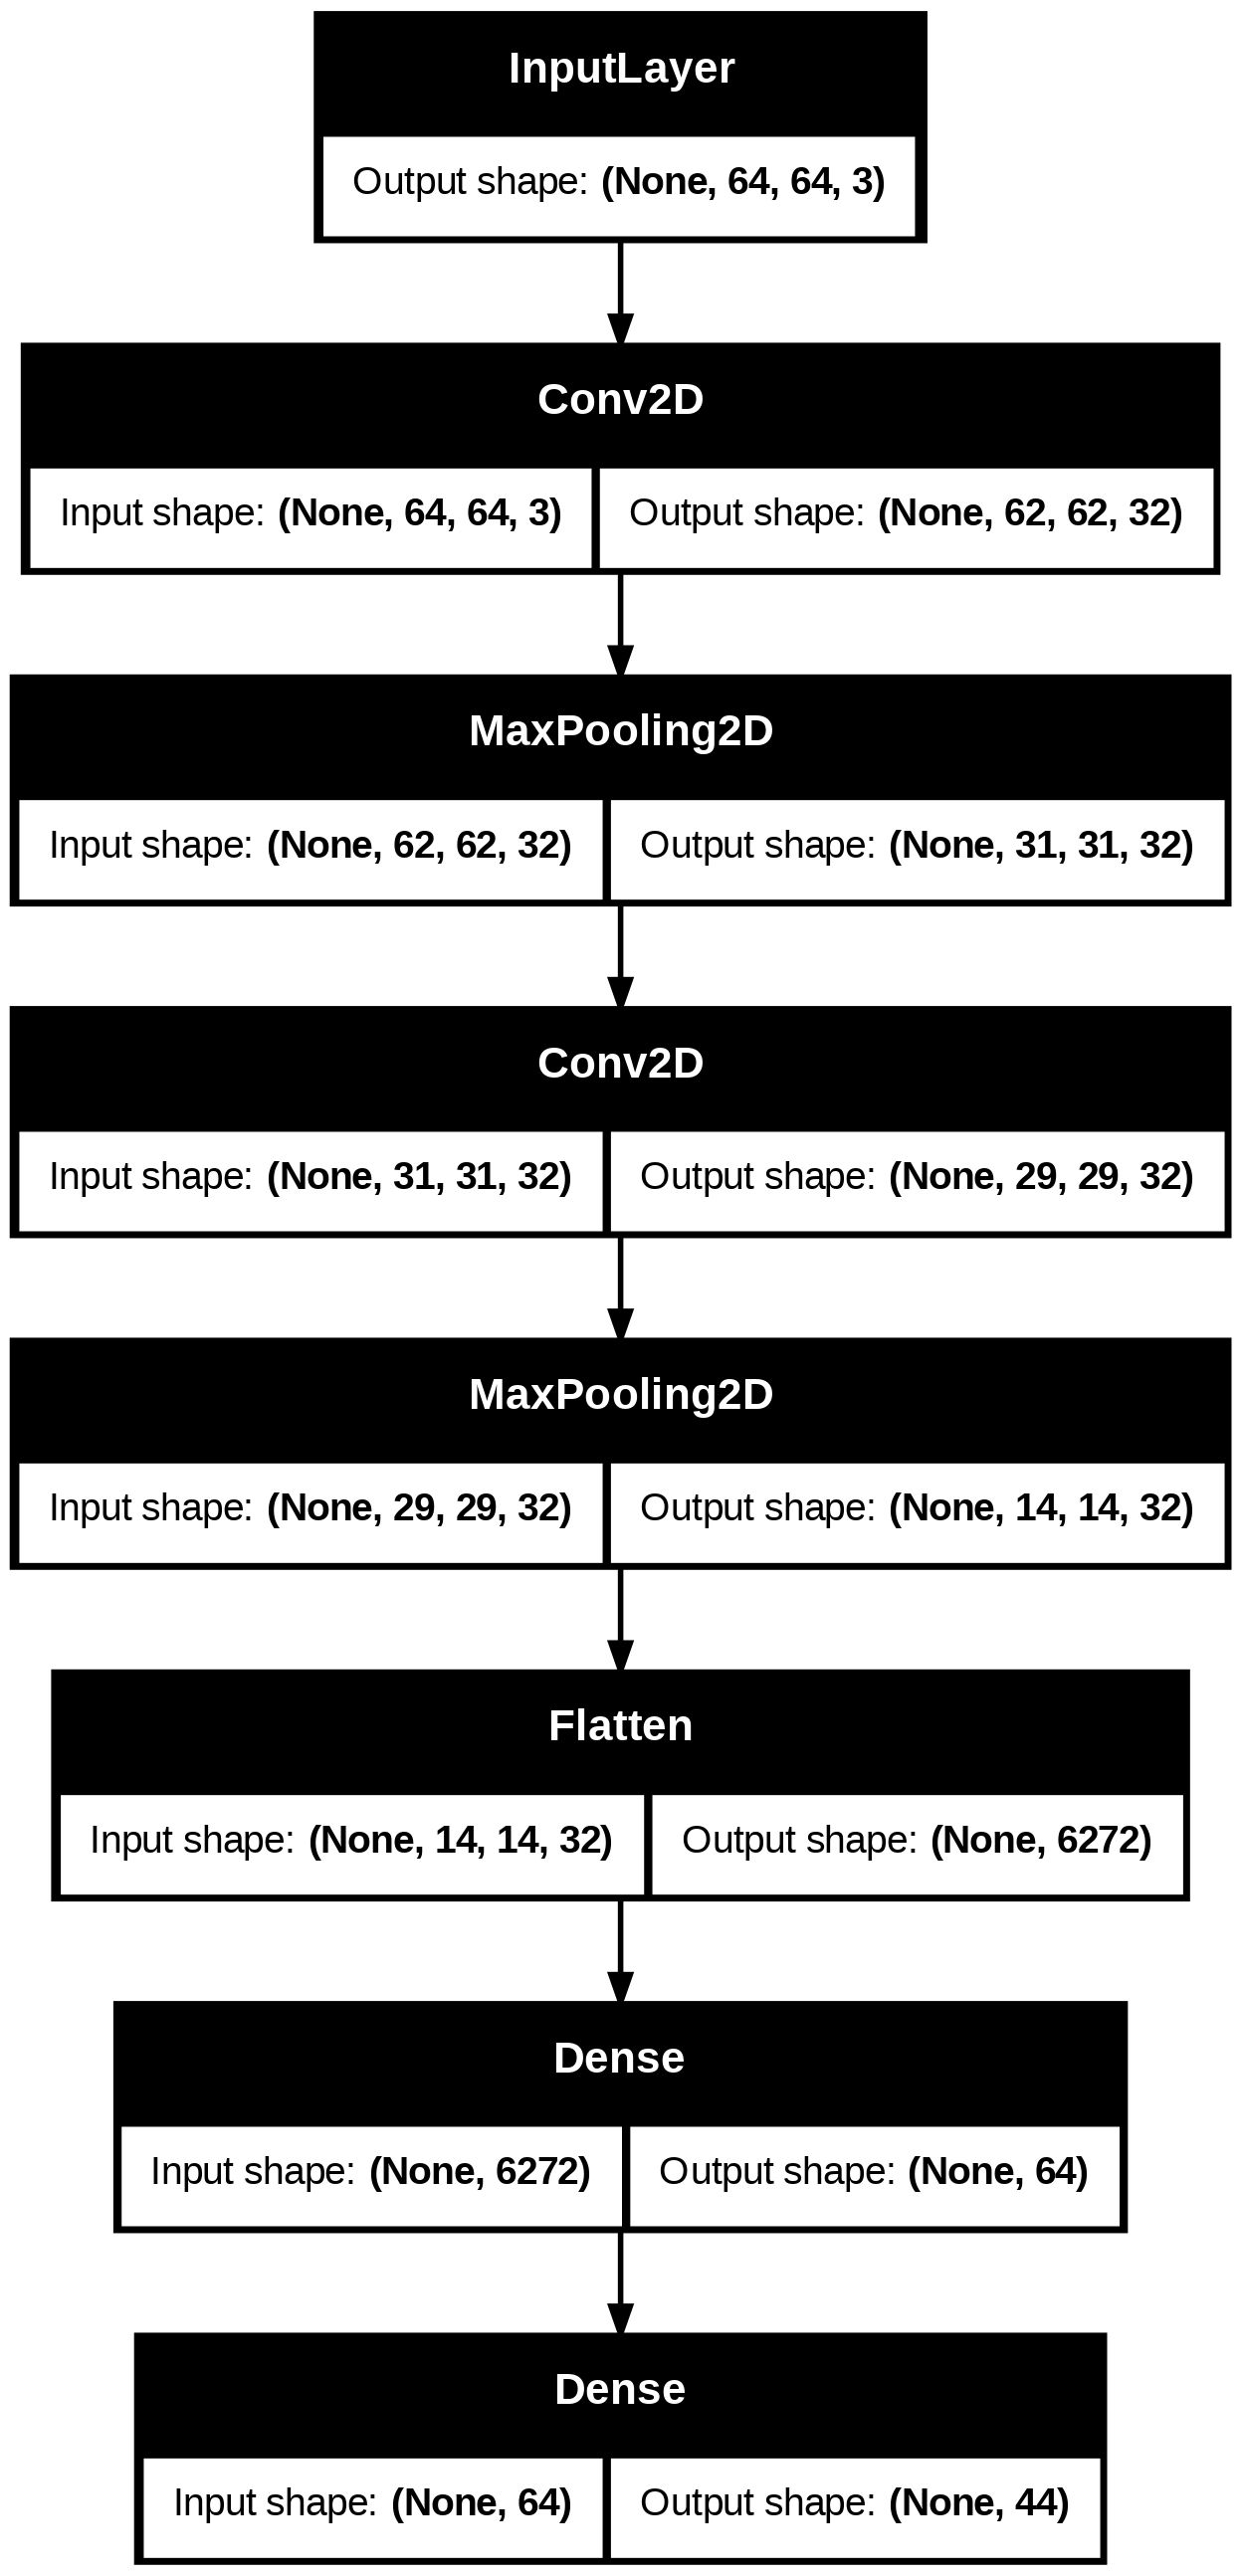

In [ ]:
plot_model(model, show_shapes=True)

In [ ]:
import tensorflow as tf
import tensorflow.keras.backend as k
from tensorflow.keras.metrics import Precision, Recall, AUC

def create_metrics():
    """
    Creates instances of various metrics for evaluating model performance.

    Returns:
        tuple: A tuple of the metrics: (recall, precision, f1_score, auc, sensitivity, specificity, mcc).
    """
    @tf.function
    def f1_score(y_true, y_pred):
        """
        Calculates the F1 score.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: F1 score.
        """
        tp = true_positive(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        precision = tp / (tp + fp + k.epsilon())
        recall = tp / (tp + fn + k.epsilon())

        return 2 * (precision * recall) / (precision + recall + k.epsilon())

    @tf.function
    def specificity(y_true, y_pred):
        """
        Calculates the specificity.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Specificity.
        """
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)

        return tn / (tn + fp + k.epsilon())

    @tf.function
    def sensitivity(y_true, y_pred):
        """
        Calculates the sensitivity.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Sensitivity.
        """
        tp = true_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        return tp / (tp + fn + k.epsilon())

    @tf.function
    def mcc(y_true, y_pred):
        """
        Calculates the Matthews correlation coefficient (MCC).

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Matthews correlation coefficient.
        """
        tp = true_positive(y_true, y_pred)
        tn = true_negative(y_true, y_pred)
        fp = false_positive(y_true, y_pred)
        fn = false_negative(y_true, y_pred)

        tp = k.cast(tp, tf.float32)
        tn = k.cast(tn, tf.float32)
        fp = k.cast(fp, tf.float32)
        fn = k.cast(fn, tf.float32)

        numerator = (tp * tn - fp * fn)
        denominator = k.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))

        return numerator / (denominator + k.epsilon())

    @tf.function
    def true_positive(y_true, y_pred):
        """
        Calculates the number of true positives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of true positives.
        """
        y_pred_pos, _, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return k.sum(y_pos * y_pred_pos)

    @tf.function
    def false_positive(y_true, y_pred):
        """
        Calculates the number of false positives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of false positives.
        """
        y_pred_pos, _, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return k.sum(y_neg * y_pred_pos)

    @tf.function
    def false_negative(y_true, y_pred):
        """
        Calculates the number of false negatives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of false negatives.
        """
        _, y_pred_neg, y_pos, _ = calculate_confusion_matrix(y_true, y_pred)
        return k.sum(y_pos * y_pred_neg)

    @tf.function
    def true_negative(y_true, y_pred):
        """
        Calculates the number of true negatives.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            Tensor: Number of true negatives.
        """
        _, y_pred_neg, _, y_neg = calculate_confusion_matrix(y_true, y_pred)
        return k.sum(y_neg * y_pred_neg)

    @tf.function
    def calculate_confusion_matrix(y_true, y_pred):
        """
        Calculates the components of the confusion matrix.

        Args:
            y_true: True labels.
            y_pred: Predicted labels.

        Returns:
            tuple: A tuple containing the components of the confusion matrix: (y_pred_pos, y_pred_neg, y_pos, y_neg).
        """
        y_pred_pos = k.cast(k.round(k.clip(y_pred, 0, 1)), tf.float32)
        y_pred_neg = 1 - y_pred_pos
        y_pos = k.cast(k.round(k.clip(y_true, 0, 1)), tf.float32)
        y_neg = 1 - y_pos
        return y_pred_pos, y_pred_neg, y_pos, y_neg

    precision_metric = Precision()
    recall_metric = Recall()
    f1_score_metric = f1_score
    specificity_metric = specificity
    sensitivity_metric = sensitivity
    mcc_metric = mcc
    auc_metric = AUC()

    return (
        precision_metric,
        recall_metric,
        f1_score_metric,
        specificity_metric,
        sensitivity_metric,
        mcc_metric,
        auc_metric,
    )

# Example usage
metrics = create_metrics()
for metric in metrics:
    print(metric)


<Precision name=precision>
<Recall name=recall>
<AUC name=auc>


In [ ]:
custom_metrics = list(create_metrics())
custom_metrics.append("accuracy")

In [ ]:
model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics = custom_metrics
#         metrics = custom_metrics

)

In [ ]:
class TimeCallback(tf.keras.callbacks.Callback):
    """Custom callback to record epoch times and total training time."""

    def on_train_begin(self, logs=None):
        """Initialize training start time and epoch times."""
        self.train_start_time = time.perf_counter()
        self.epoch_times = []

    def on_epoch_begin(self, epoch, logs=None):
        """Record start time of each epoch."""
        self.epoch_start_time = time.perf_counter()

    def on_epoch_end(self, epoch, logs=None):
        """Calculate and store epoch time."""
        epoch_time = time.perf_counter() - self.epoch_start_time
        self.epoch_times.append(epoch_time)

    def on_train_end(self, logs=None):
        """Calculate total training time."""
        self.total_train_time = time.perf_counter() - self.train_start_time

# Create an instance of the TimeCallback
time_callback = TimeCallback()

In [ ]:
import tensorflow as tf
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2

# Create Concrete Function
@tf.function
def forward(x):
    return model(x)

concrete_func = forward.get_concrete_function(
    tf.TensorSpec([1, 64, 64, 3], tf.float32)
)

# Freeze graph
frozen_func = convert_variables_to_constants_v2(concrete_func)
graph = frozen_func.graph

# Calculate FLOPs
with graph.as_default():
    run_meta = tf.compat.v1.RunMetadata()

    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()

    flops = tf.compat.v1.profiler.profile(
        graph=graph,
        run_meta=run_meta,
        cmd='op',
        options=opts
    )

print(f"FLOPs : {flops.total_float_ops:,}")
print(f"GFLOPs: {flops.total_float_ops/1e9:.6f}")
print(f"Parameters: {model.count_params():,}")

Instructions for updating:
This API was designed for TensorFlow v1. See https://www.tensorflow.org/guide/migrate for instructions on how to migrate your code to TensorFlow v2.


FLOPs : 23,250,536
GFLOPs: 0.023251
Parameters: 414,476


In [ ]:
TOTAL_EPOCHS = 40

history = model.fit(
    train_gen,
    epochs=TOTAL_EPOCHS,
    steps_per_epoch=train_steps,
    validation_data=valid_gen,
    validation_steps=val_steps,
    callbacks=[time_callback]
)

Epoch 1/40
358/358 ━━━━━━━━━━━━━━━━━━━━ 40s 75ms/step - accuracy: 0.2043 - auc_1: 0.7553 - f1_score: 0.1002 - loss: 6.1577 - mcc: 0.1285 - precision_1: 0.4323 - recall_1: 0.0637 - sensitivity: 0.0635 - specificity: 0.9981 - val_accuracy: 0.3385 - val_auc_1: 0.8654 - val_f1_score: 0.1731 - val_loss: 2.6649 - val_mcc: 0.2233 - val_precision_1: 0.6240 - val_recall_1: 0.1096 - val_sensitivity: 0.1096 - val_specificity: 0.9985
Epoch 2/40
358/358 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2500 - auc_1: 0.8973 - f1_score: 0.2000 - loss: 2.6472 - mcc: 0.2421 - precision_1: 0.5000 - recall_1: 0.1250 - sensitivity: 0.1250 - specificity: 0.9971 - val_accuracy: 0.3371 - val_auc_1: 0.8654 - val_f1_score: 0.1765 - val_loss: 2.6593 - val_mcc: 0.2133 - val_precision_1: 0.6385 - val_recall_1: 0.1166 - val_sensitivity: 0.1166 - val_specificity: 0.9985
Epoch 3/40
358/358 ━━━━━━━━━━━━━━━━━━━━ 11s 32ms/step - accuracy: 0.4888 - auc_1: 0.9222 - f1_score: 0.4135 - loss: 2.0038 - mcc: 0.4512 - precision_1

In [ ]:
execution_time_parts = []
avg_time_parts = []

for unit in [(3600, 'hours'), (60, 'minutes'), (1, 'seconds'), (0.001, 'milliseconds')]:
    total_value = int(time_callback.total_train_time // unit[0])
    avg_value = int(np.mean(time_callback.epoch_times) // unit[0])

    if total_value > 0 or unit[0] == 0.001:
        execution_time_parts.append((total_value, unit[1]))
    if avg_value > 0 or unit[0] == 0.001:
        avg_time_parts.append((avg_value, unit[1]))

    time_callback.total_train_time -= total_value * unit[0]
    time_callback.epoch_times = [time - avg_value * unit[0] for time in time_callback.epoch_times]

execution_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in execution_time_parts if value > 0
])

avg_time_string = ", ".join([
    f"{value:02d} {unit_str}" for value, unit_str in avg_time_parts if value > 0
])

print(f"Model training took {execution_time_string}")
print(f"Average time per epoch: {avg_time_string}")

Model training took 05 minutes, 16 seconds, 820 milliseconds
Average time per epoch: 07 seconds, 909 milliseconds


In [ ]:
_ = model.evaluate(test_gen, steps=test_steps)

112/112 ━━━━━━━━━━━━━━━━━━━━ 7s 58ms/step - accuracy: 0.7073 - auc_1: 0.9042 - f1_score: 0.7109 - loss: 2.8891 - mcc: 0.7045 - precision_1: 0.7187 - recall_1: 0.7050 - sensitivity: 0.7050 - specificity: 0.9936


In [ ]:
from keras.metrics import Precision, Recall, AUC

In [ ]:
import matplotlib.pyplot as plt
import math

def find_metric_name(metric_dict, base_name):
    """
    Find the metric name in the history dictionary that matches the base name, handling suffixes.
    """
    for key in metric_dict.keys():
        if key.startswith(base_name):
            return key
    return None

def plot_metrics(hist, metric_name_list):
    """
    Plots the given metrics for the training and validation sets.

    Args:
        hist: a Keras History object containing the training history
        metric_name_list: a list of strings representing the names of the metrics to plot

    Returns:
        None
    """
    num_metrics = len(metric_name_list)
    figure, axes = plt.subplots(num_metrics, figsize=(10, 6 * num_metrics))

    # Handle the case where there's only one metric to plot
    if num_metrics == 1:
        axes = [axes]

    for ax, metric_n in zip(axes, metric_name_list):
        metric_key = find_metric_name(hist.history, metric_n.lower())
        val_metric_key = find_metric_name(hist.history, f"val_{metric_n.lower()}")

        if metric_key and val_metric_key:
            metric = hist.history[metric_key]
            v_metric = hist.history[val_metric_key]

            rng = range(1, len(metric) + 1)
            ax.plot(rng, metric, label=metric_key)
            ax.plot(rng, v_metric, label=val_metric_key)
            ax.legend()
            ax.set_xlabel("Epochs")

            if metric_n in ("auc", "mcc"):
                ax.set_ylabel(metric_n.upper())
                ax.set_title(metric_n.upper() + " vs Epochs")
            else:
                ax.set_ylabel(metric_n.capitalize())
                ax.set_title(metric_n.capitalize() + " vs Epochs")

            max_metric = max(max(metric), max(v_metric))
            min_metric = min(min(metric), min(v_metric))
            y_max = math.ceil(max_metric)

            if min_metric > 0 or max_metric > 1:
                ax.set_ylim(0, y_max)
            else:
                ax.set_ylim(min_metric, y_max)

            ax.grid(True, linestyle='--', alpha=0.5)
            ax.set_xlim(1, len(metric))
        else:
            print(f"Metric '{metric_n}' not found in history. Skipping this metric.")

    plt.tight_layout()
    plt.show()

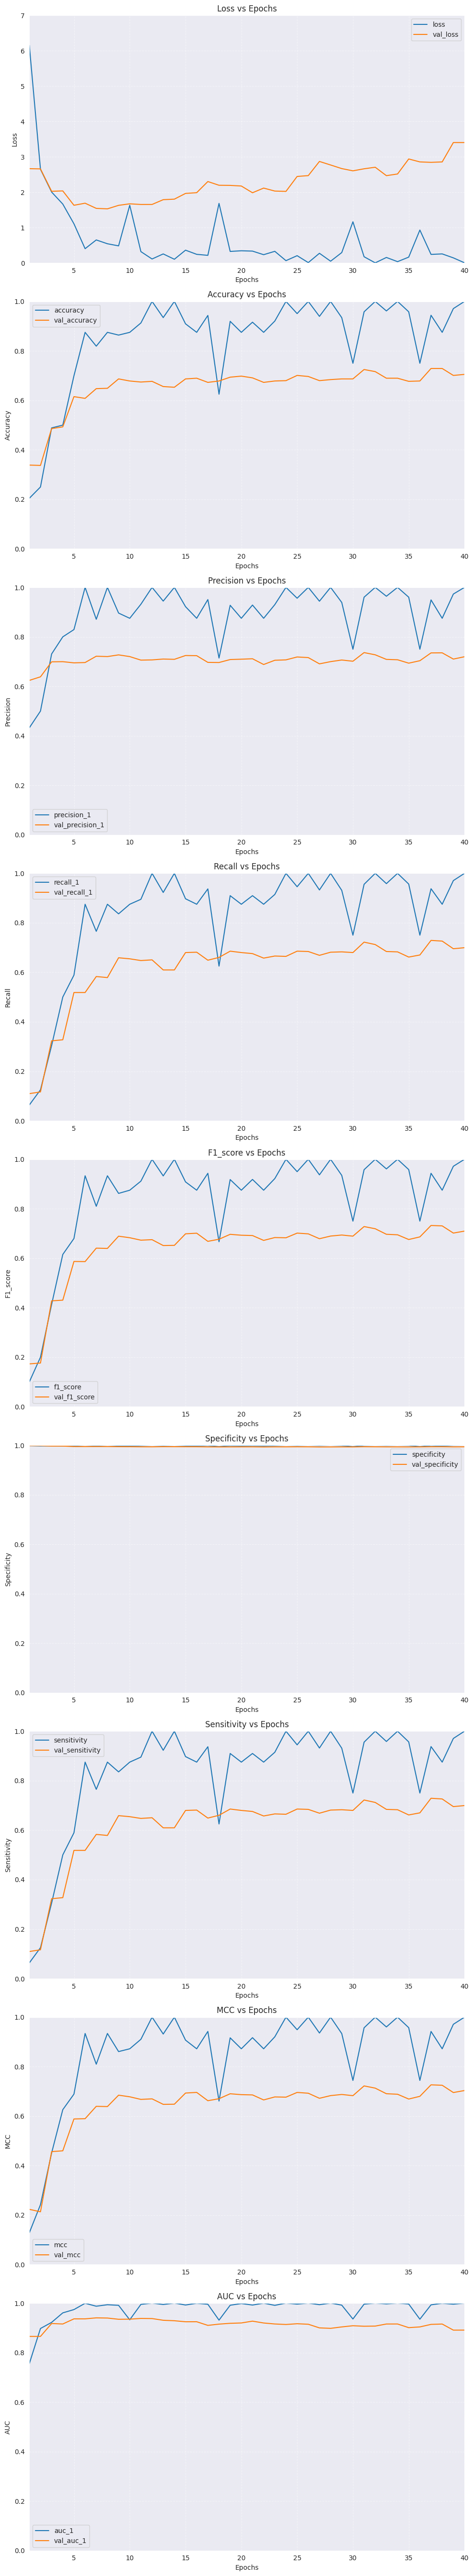

In [ ]:
metric_names = ["loss", "accuracy", "precision", "recall", "f1_score",
                "specificity", "sensitivity", "mcc", "auc"]
plot_metrics(history, metric_names)

In [ ]:
def generate_classification_report(model, test_generator, test_steps, batch_size, target_names):
    """
    Generate a classification report, accuracy, and number of errors for a given model and test generator.

    Args:
        model (object): The trained model.
        test_generator (object): The test data generator.
        test_steps (int): The number of steps to iterate over the test generator.
        batch_size (int): The batch size for generating predictions.
        target_names (list): List of target class names for the classification report.

    Returns:
        tuple: A tuple containing true labels, predicted labels, and the classification report.
    """
    predicted_labels = []
    true_labels = []

    for i in range(test_steps):
        batch_data, batch_true_labels = next(test_generator)

        batch_predicted_labels = model.predict_on_batch(batch_data)
        batch_predicted_labels = np.argmax(batch_predicted_labels, axis=1)

        predicted_labels.extend(batch_predicted_labels)
        true_labels.extend(batch_true_labels)

    true_labels = np.array(true_labels)

    if len(true_labels[0]) > 1:
        true_labels = np.argmax(true_labels, axis=1)

    report = classification_report(
        true_labels,
        predicted_labels,
        target_names=target_names,
        digits=4,
        zero_division=1
    )

    accuracy = accuracy_score(true_labels, predicted_labels)
    num_errors = np.sum(true_labels != predicted_labels)

    print(report)
    print(f'There were {num_errors} errors in {len(predicted_labels)} tests for an accuracy of {accuracy*100:6.2f}')

    return true_labels, predicted_labels

In [ ]:
true_labels, predicted_labels = generate_classification_report(
    model, test_gen, test_steps, BATCH_SIZE, df["label"].unique()
)

                        precision    recall  f1-score   support

        Astrocitoma T1     0.5122    0.6000    0.5526        35
      Astrocitoma T1C+     0.8462    0.4783    0.6111        46
        Astrocitoma T2     0.5581    0.7059    0.6234        34
          Carcinoma T1     0.9231    0.9231    0.9231        13
        Carcinoma T1C+     0.8696    0.9091    0.8889        22
          Carcinoma T2     1.0000    1.0000    1.0000        15
         Ependimoma T1     0.6667    0.4444    0.5333         9
       Ependimoma T1C+     0.1667    0.1000    0.1250        10
         Ependimoma T2     0.5000    0.2727    0.3529        11
      Ganglioglioma T1     1.0000    1.0000    1.0000         4
    Ganglioglioma T1C+     0.7500    1.0000    0.8571         3
      Ganglioglioma T2     0.5000    0.4000    0.4444         5
          Germinoma T1     0.4286    0.6000    0.5000         5
        Germinoma T1C+     0.4000    0.7500    0.5217         8
          Germinoma T2     1.0000    0.

In [ ]:
def confusion_matrix(true_labels, predicted_labels, num_classes):
    """
    Compute the confusion matrix.

    Args:
        true_labels (list or numpy.ndarray): Array-like object of true labels.
        predicted_labels (list or numpy.ndarray): Array-like object of predicted labels.
        num_classes (int): Number of classes.

    Returns:
        numpy.ndarray: Confusion matrix.
    """
    cm = np.zeros((num_classes, num_classes), dtype=int)
    np.add.at(cm, (true_labels, predicted_labels), 1)
    return cm

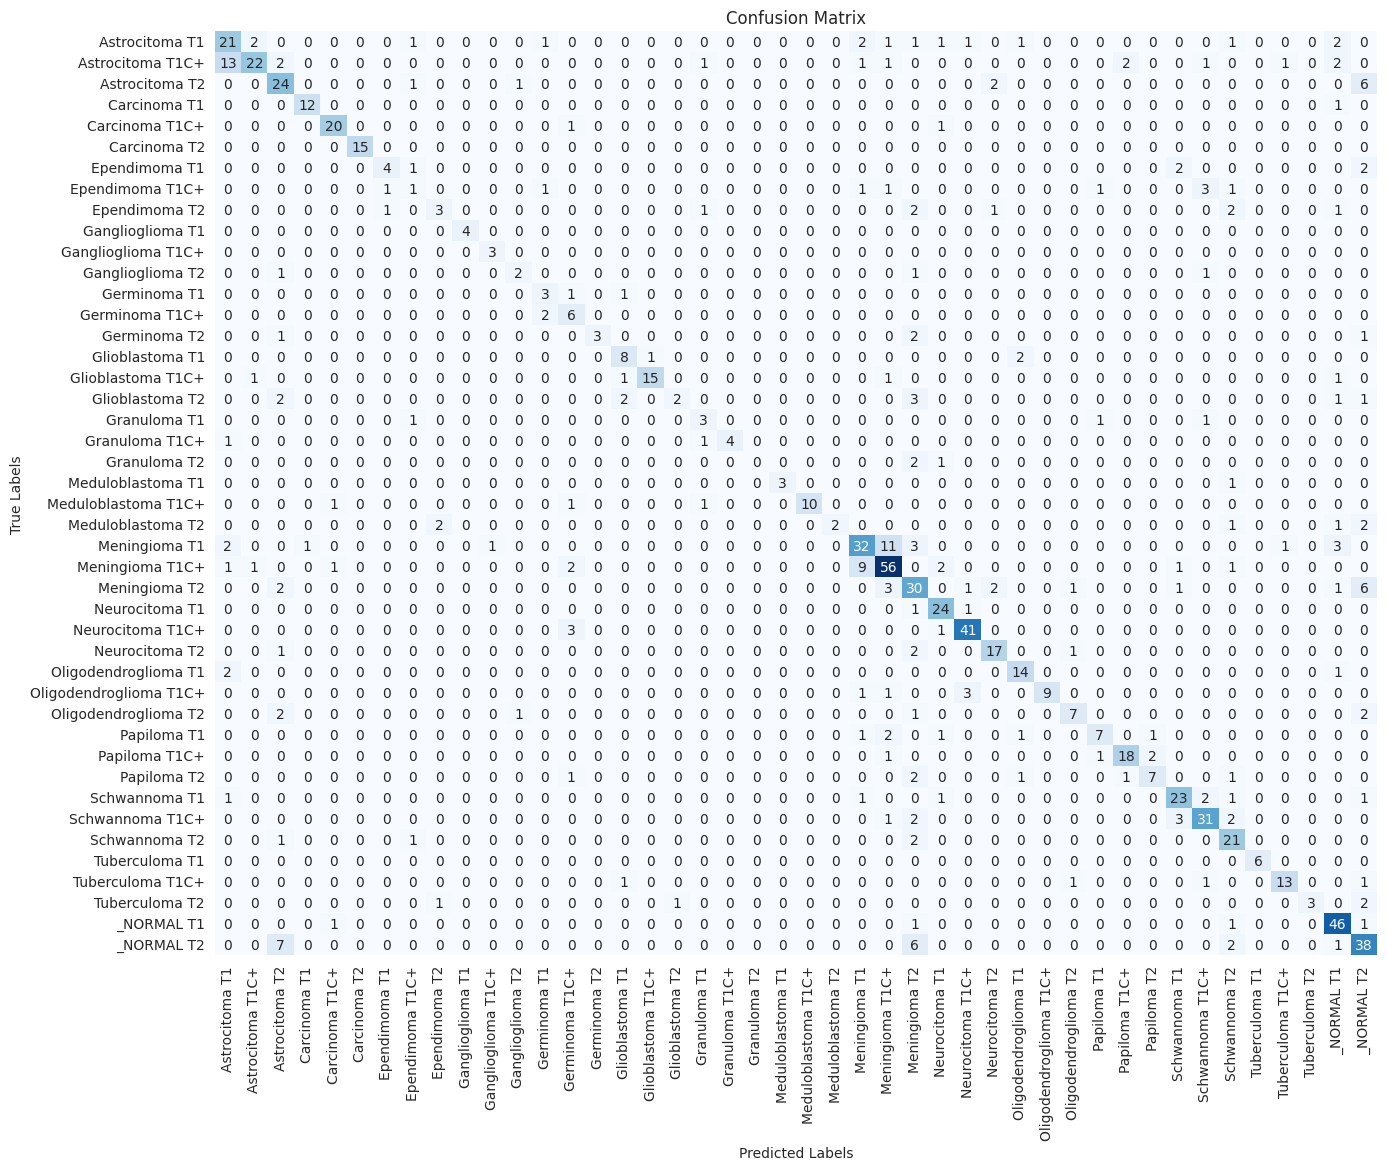

In [ ]:
cm = confusion_matrix(true_labels, predicted_labels, num_classes)

plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=df["label"].unique(), yticklabels=df["label"].unique())

plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()